1. What is IoT?

IoT (Internet of Things) = Devices (sensors/actuators) + Connectivity (Wi-Fi/MQTT/HTTP) + Cloud/Server + Data Processing.

In real IoT:

Sensors collect data (temperature, motion, etc.)

Devices send data to the cloud (MQTT/HTTP)

Cloud processes and stores data

Applications analyze and visualize

Since you don’t have hardware, we’ll simulate sensors with random data in Jupyter.

2. Simulating Sensors (No Hardware)

In [1]:
import random
import time

# Simulated sensors
def get_temperature():
    return round(random.uniform(20, 35), 2)  # Celsius

def get_humidity():
    return round(random.uniform(30, 70), 2)  # %

# Collect readings
for i in range(5):
    temp = get_temperature()
    hum = get_humidity()
    print(f"Reading {i+1}: Temperature={temp}°C, Humidity={hum}%")
    time.sleep(1)


Reading 1: Temperature=32.72°C, Humidity=60.29%
Reading 2: Temperature=20.4°C, Humidity=63.47%
Reading 3: Temperature=31.7°C, Humidity=36.28%
Reading 4: Temperature=20.81°C, Humidity=62.63%
Reading 5: Temperature=20.5°C, Humidity=55.93%


3. Storing IoT Data (Local Database)

We often store IoT readings in a database. For simulation, we’ll use SQLite.

In [2]:
import sqlite3
import datetime

# Create DB
conn = sqlite3.connect("iot_data.db")
cur = conn.cursor()

# Create table
cur.execute("""
CREATE TABLE IF NOT EXISTS sensor_data (
    timestamp TEXT,
    temperature REAL,
    humidity REAL
)
""")

# Insert simulated readings
for _ in range(5):
    temp = get_temperature()
    hum = get_humidity()
    ts = datetime.datetime.now().isoformat()
    cur.execute("INSERT INTO sensor_data VALUES (?, ?, ?)", (ts, temp, hum))
    conn.commit()

print("Data inserted into database!")


Data inserted into database!


4. Visualizing IoT Data (Graphs)

IoT dashboards visualize trends. Let’s use matplotlib.

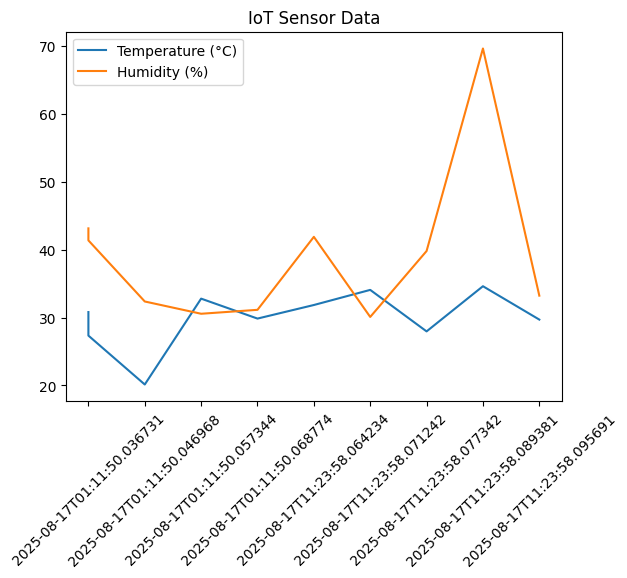

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# Load from DB
df = pd.read_sql_query("SELECT * FROM sensor_data", conn)

# Plot
plt.plot(df["timestamp"], df["temperature"], label="Temperature (°C)")
plt.plot(df["timestamp"], df["humidity"], label="Humidity (%)")
plt.xticks(rotation=45)
plt.legend()
plt.title("IoT Sensor Data")
plt.show()


5. IoT Communication with MQTT (Simulation)

IoT devices often use MQTT to talk to servers.
We can simulate MQTT with paho-mqtt.



In [4]:
import paho.mqtt.client as mqtt
import json

# MQTT broker (free public broker)
broker = "test.mosquitto.org"
topic = "demo/iot/sensor"

# Publisher
client = mqtt.Client()
client.connect(broker, 1883, 60)

for i in range(3):
    data = {"temperature": get_temperature(), "humidity": get_humidity()}
    client.publish(topic, json.dumps(data))
    print("Published:", data)


C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_4856\1408454722.py:9: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


Published: {'temperature': 28.1, 'humidity': 40.43}
Published: {'temperature': 27.88, 'humidity': 44.57}
Published: {'temperature': 33.12, 'humidity': 35.4}


6. IoT Dashboard with Real-Time Updates

We’ll simulate real-time IoT dashboard using matplotlib.animation.

C:\Users\KRISHNENDU\AppData\Local\Temp\ipykernel_4856\304995237.py:24: UserWarning: frames=None which we can infer the length of, did not pass an explicit *save_count* and passed cache_frame_data=True.  To avoid a possibly unbounded cache, frame data caching has been disabled. To suppress this warning either pass `cache_frame_data=False` or `save_count=MAX_FRAMES`.
  ani = animation.FuncAnimation(fig, animate, interval=1000)


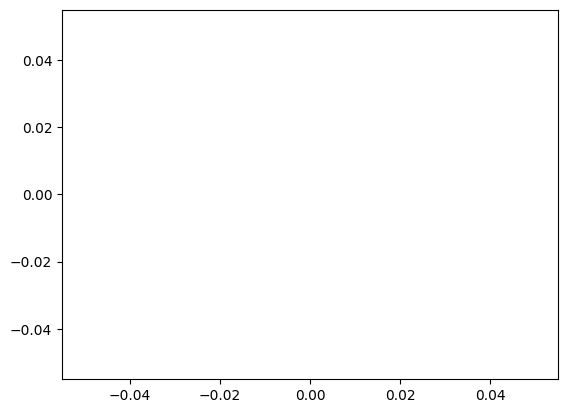

In [5]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

temps, hums = [], []

fig, ax = plt.subplots()
line1, = ax.plot([], [], label="Temperature (°C)")
line2, = ax.plot([], [], label="Humidity (%)")

def animate(i):
    temp = get_temperature()
    hum = get_humidity()
    temps.append(temp)
    hums.append(hum)
    
    line1.set_data(range(len(temps)), temps)
    line2.set_data(range(len(hums)), hums)
    
    ax.relim()
    ax.autoscale_view()
    ax.legend()
    return line1, line2

ani = animation.FuncAnimation(fig, animate, interval=1000)
plt.show()


7. IoT Data Processing (Anomaly Detection)

IoT systems often detect abnormal values (e.g., fire alarm).

In [6]:
import random
def detect_anomaly(temp, hum):
    if temp > 32:
        return "🔥 High Temperature Alert!"
    if hum < 35:
        return "💧 Low Humidity Alert!"
    return "✅ Normal"

# Simulated temperature sensor
def get_temperature():
    return round(random.uniform(20, 35), 2)  # Celsius

# Simulated humidity sensor
def get_humidity():
    return round(random.uniform(30, 70), 2)  # %

for i in range(10):
    t, h = get_temperature(), get_humidity()
    print(f"Temp={t}, Hum={h} → {detect_anomaly(t, h)}")


Temp=29.45, Hum=37.98 → ✅ Normal
Temp=33.12, Hum=34.59 → 🔥 High Temperature Alert!
Temp=30.02, Hum=33.11 → 💧 Low Humidity Alert!
Temp=28.29, Hum=59.89 → ✅ Normal
Temp=31.77, Hum=31.4 → 💧 Low Humidity Alert!
Temp=31.11, Hum=35.84 → ✅ Normal
Temp=20.95, Hum=31.37 → 💧 Low Humidity Alert!
Temp=24.3, Hum=38.97 → ✅ Normal
Temp=21.67, Hum=66.71 → ✅ Normal
Temp=30.03, Hum=37.54 → ✅ Normal


8. IoT REST API (Simulated Device → Cloud)

Devices often send data to the cloud REST API.
We’ll use Flask to simulate a cloud server.

In [ ]:
from flask import Flask, request, jsonify

app = Flask(__name__)

data_store = []

@app.route("/upload", methods=["POST"])
def upload():
    data = request.json
    data_store.append(data)
    return jsonify({"status": "success", "data": data}), 200

@app.route("/data", methods=["GET"])
def get_data():
    return jsonify(data_store), 200

app.run(port=5000)


 * Serving Flask app '__main__'
 * Debug mode: off


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit


9. IoT Cloud Communication (HTTP Device Client)

Now simulate device sending data to the above Flask server.

In [ ]:
import requests

url = "http://127.0.0.1:5000/upload"

for i in range(5):
    payload = {"temperature": get_temperature(), "humidity": get_humidity()}
    res = requests.post(url, json=payload)
    print(res.json())


10. IoT Data Analytics

We can do basic analytics on IoT data stored in DB/Cloud.

In [ ]:
df.describe()  # gives mean, min, max, std

# Example: Find hottest reading
max_temp = df["temperature"].max()
print("Max Temp:", max_temp)


11. IoT Device-to-Device Communication

Two devices can communicate via MQTT topics.

Device 1 publishes temperature.

Device 2 subscribes and reacts.

In [ ]:
# Subscriber
def on_message(client, userdata, msg):
    data = json.loads(msg.payload.decode())
    print("Device 2 received:", data)
    if data["temperature"] > 32:
        print("Device 2 → Switch ON Fan")

client = mqtt.Client()
client.on_message = on_message
client.connect(broker, 1883, 60)
client.subscribe(topic)
client.loop_start()


12. IoT + AI/ML (Predictive Maintenance)

We can use ML to predict sensor trends (no hardware needed).

Example: Predict future temperature with linear regression.

In [ ]:
from sklearn.linear_model import LinearRegression
import numpy as np

X = np.array(range(len(df))).reshape(-1,1)
y = df["temperature"]

model = LinearRegression().fit(X, y)

future = np.array([[len(df)+i] for i in range(5)])
preds = model.predict(future)

print("Predicted future temps:", preds)


13. IoT Security Basics (Encryption Simulation)

IoT devices must secure data. Example: AES encryption.

In [ ]:
from cryptography.fernet import Fernet

key = Fernet.generate_key()
cipher = Fernet(key)

msg = "Temperature=30, Humidity=55"
encrypted = cipher.encrypt(msg.encode())
decrypted = cipher.decrypt(encrypted).decode()

print("Encrypted:", encrypted)
print("Decrypted:", decrypted)
